# 02 — Drift Detection Demo

This notebook demonstrates the drift detection subsystem:
- Generate reference vs drifted distributions
- Run KS test, PSI, Wasserstein distance
- Visualize distributions and drift scores
- Trigger monitoring endpoint

**Prerequisites**: `uv pip install matplotlib`

In [1]:
import numpy as np
from scipy import stats

np.random.seed(42)

## 1. Generate Reference & Current Distributions

In [2]:
# Reference: training data distribution
reference = np.random.normal(loc=50, scale=10, size=1000)

# Case 1: No drift (same distribution)
no_drift = np.random.normal(loc=50, scale=10, size=500)

# Case 2: Moderate drift (shifted mean)
moderate_drift = np.random.normal(loc=55, scale=12, size=500)

# Case 3: Severe drift (completely different)
severe_drift = np.random.normal(loc=70, scale=5, size=500)

print(f"Reference:     mean={reference.mean():.2f}, std={reference.std():.2f}")
print(f"No drift:      mean={no_drift.mean():.2f}, std={no_drift.std():.2f}")
print(f"Moderate drift: mean={moderate_drift.mean():.2f}, std={moderate_drift.std():.2f}")
print(f"Severe drift:  mean={severe_drift.mean():.2f}, std={severe_drift.std():.2f}")

Reference:     mean=50.19, std=9.79
No drift:      mean=51.08, std=10.09
Moderate drift: mean=55.40, std=11.80
Severe drift:  mean=69.94, std=4.79


## 2. Kolmogorov-Smirnov Test

In [3]:
SIGNIFICANCE = 0.05

for name, current in [("No drift", no_drift), ("Moderate", moderate_drift), ("Severe", severe_drift)]:
    stat, p_value = stats.ks_2samp(reference, current)
    drifted = p_value < SIGNIFICANCE
    icon = "\u274c DRIFT" if drifted else "\u2705 OK"
    print(f"{name:15s} | KS stat={stat:.4f} | p-value={p_value:.6f} | {icon}")

No drift        | KS stat=0.0620 | p-value=0.152051 | ✅ OK
Moderate        | KS stat=0.2140 | p-value=0.000000 | ❌ DRIFT
Severe          | KS stat=0.8510 | p-value=0.000000 | ❌ DRIFT


## 3. Population Stability Index (PSI)

In [4]:
def compute_psi(reference: np.ndarray, current: np.ndarray, n_bins: int = 10) -> float:
    bins = np.percentile(reference, np.linspace(0, 100, n_bins + 1))
    bins[0], bins[-1] = -np.inf, np.inf
    eps = 1e-10
    ref_pct = np.clip(np.histogram(reference, bins=bins)[0] / len(reference), eps, 1)
    cur_pct = np.clip(np.histogram(current, bins=bins)[0] / len(current), eps, 1)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

for name, current in [("No drift", no_drift), ("Moderate", moderate_drift), ("Severe", severe_drift)]:
    psi = compute_psi(reference, current)
    level = "SEVERE" if psi > 0.25 else "MODERATE" if psi > 0.1 else "OK"
    print(f"{name:15s} | PSI={psi:.4f} | {level}")

No drift        | PSI=0.0175 | OK
Moderate        | PSI=0.2813 | SEVERE
Severe          | PSI=14.9425 | SEVERE


## 4. Wasserstein Distance (Earth Mover's Distance)

In [5]:
for name, current in [("No drift", no_drift), ("Moderate", moderate_drift), ("Severe", severe_drift)]:
    dist = stats.wasserstein_distance(reference, current)
    print(f"{name:15s} | Wasserstein={dist:.4f}")

No drift        | Wasserstein=0.9880
Moderate        | Wasserstein=5.3207
Severe          | Wasserstein=19.7551


## 5. Visualize Distributions

Run this cell if you have matplotlib installed.

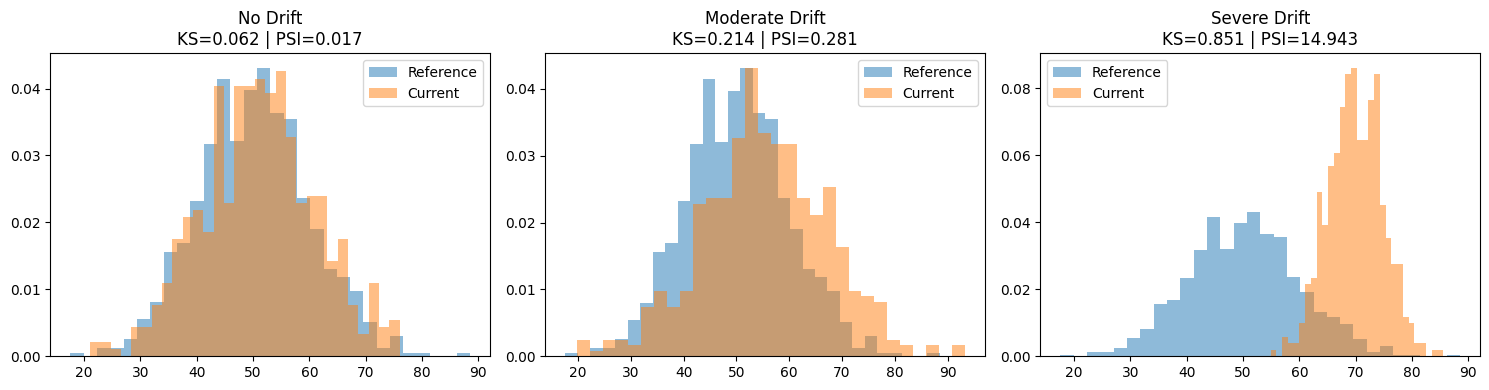

Saved: drift_comparison.png


In [6]:
try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, (name, current) in zip(axes, [("No Drift", no_drift), ("Moderate Drift", moderate_drift), ("Severe Drift", severe_drift)]):
        ax.hist(reference, bins=30, alpha=0.5, label="Reference", density=True)
        ax.hist(current, bins=30, alpha=0.5, label="Current", density=True)
        ks_stat, p = stats.ks_2samp(reference, current)
        psi = compute_psi(reference, current)
        ax.set_title(f"{name}\nKS={ks_stat:.3f} | PSI={psi:.3f}")
        ax.legend()
    plt.tight_layout()
    plt.savefig("drift_comparison.png", dpi=150)
    plt.show()
    print("Saved: drift_comparison.png")
except ImportError:
    print("matplotlib not installed — skipping visualization")